## Import

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## BGR to RGB

In [2]:
img = cv2.imread('assets/gambar-nama.jpeg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

## Detect red, green, and blue colors from the image

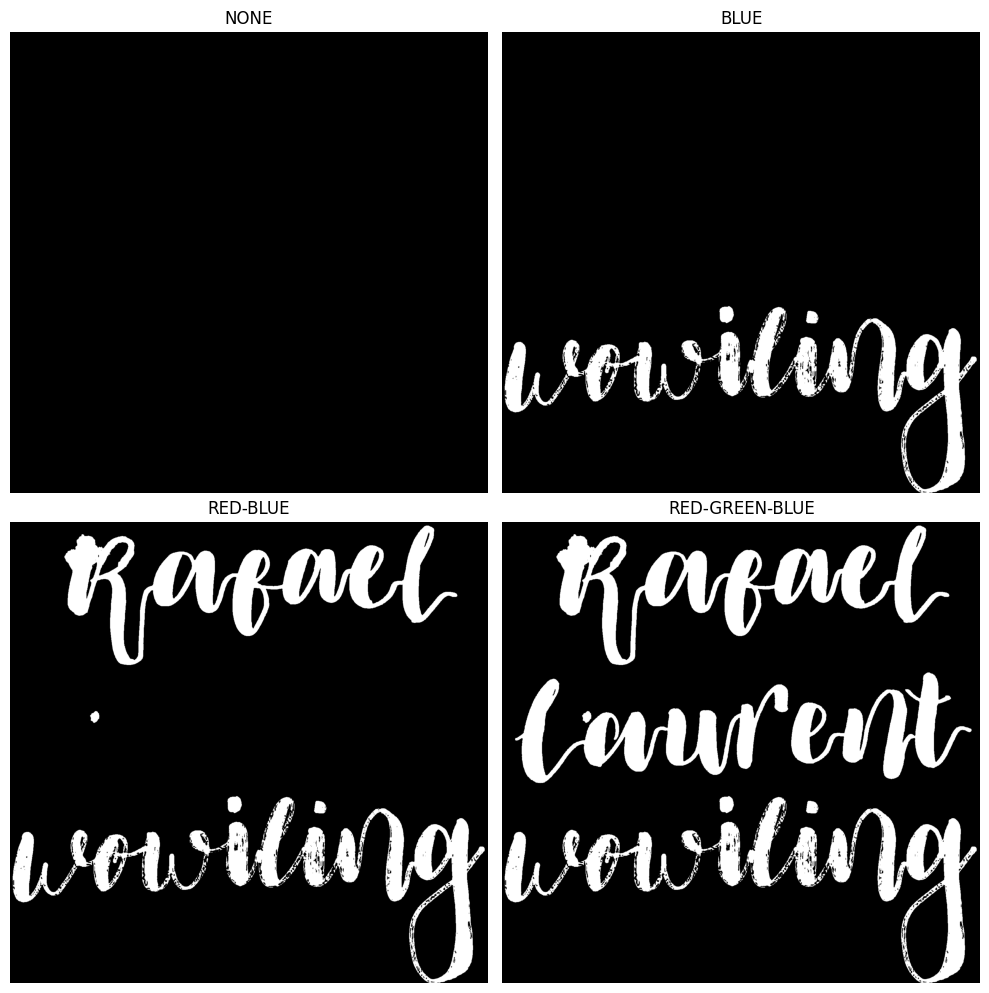

In [3]:
image_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

red_low1 = np.array([0, 50, 50])
red_up1 = np.array([10, 255, 255])
red_low2 = np.array([170, 50, 50])
red_up2 = np.array([180, 255, 255])
green_low = np.array([26, 40, 40])
green_up = np.array([86, 255, 255])
blue_low = np.array([100, 50, 50])
blue_up = np.array([140, 255, 255])

mask_red1 = cv2.inRange(image_hsv, red_low1, red_up1)
mask_red2 = cv2.inRange(image_hsv, red_low2, red_up2)
mask_red = cv2.bitwise_or(mask_red1, mask_red2)
mask_green = cv2.inRange(image_hsv, green_low, green_up)
mask_blue = cv2.inRange(image_hsv, blue_low, blue_up)

combined_mask1 = cv2.bitwise_or(mask_red, mask_blue)
combined_mask2 = cv2.bitwise_or(combined_mask1, mask_green)

(thresh, binary1) = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY)

axs[0, 0].imshow(binary1, cmap='gray')
axs[0, 0].set_title('NONE')
axs[0, 0].axis('off')

axs[0, 1].imshow(mask_blue, cmap='gray')
axs[0, 1].set_title('BLUE')
axs[0, 1].axis('off')

axs[1, 0].imshow(combined_mask1, cmap='gray')
axs[1, 0].set_title('RED-BLUE')
axs[1, 0].axis('off')

axs[1, 1].imshow(combined_mask2, cmap='gray')
axs[1, 1].set_title('RED-GREEN-BLUE')
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()